<a href="https://colab.research.google.com/github/mehtab-ratnani/SPAM-MAIL-CLASSIFIER/blob/main/SPAM_MAIL_MSG_CLASSIFIER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn nltk joblib -q
print("All libraries installed successfully!")

All libraries installed successfully!


In [ ]:
import os, re, string, warnings, json
import urllib.request, zipfile, io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings('ignore')

# NLTK setup
import nltk
for pkg in ['stopwords', 'wordnet', 'punkt']:
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score
)

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print("All imports successful!")
print(f"   NumPy    : {np.__version__}")
print(f"   Pandas   : {pd.__version__}")

All imports successful!
   NumPy    : 2.0.2
   Pandas   : 2.2.2


In [ ]:
def load_dataset():
    print(" Downloading SMS Spam Collection dataset...")
    try:
        url = ('https://archive.ics.uci.edu/ml/machine-learning-databases'
               '/00228/smsspamcollection.zip')
        with urllib.request.urlopen(url, timeout=20) as resp:
            zf = zipfile.ZipFile(io.BytesIO(resp.read()))
            with zf.open('SMSSpamCollection') as f:
                df = pd.read_csv(f, sep='\t', header=None,
                                 names=['label', 'message'])
        print(f"[✓] Downloaded from UCI — {len(df):,} messages")
    except Exception as e:
        print(f"[!] UCI failed ({e}), using GitHub mirror...")
        url = ('https://raw.githubusercontent.com/justmarkham/'
               'pycon-2016-tutorial/master/data/sms.tsv')
        df = pd.read_csv(url, sep='\t', header=None,
                         names=['label', 'message'])
        print(f"Downloaded from GitHub — {len(df):,} messages")
    return df

df = load_dataset()

print(f"\n Dataset Summary")
print(f"   Total messages : {len(df):,}")
print(f"   Spam messages  : {(df['label']=='spam').sum():,} ({(df['label']=='spam').mean()*100:.1f}%)")
print(f"   Ham messages   : {(df['label']=='ham').sum():,} ({(df['label']=='ham').mean()*100:.1f}%)")
print(f"\n First 5 rows:")
df.head()

[✓] Downloaded from UCI — 5,572 messages

 Dataset Summary
   Total messages : 5,572
   Spam messages  : 747 (13.4%)
   Ham messages   : 4,825 (86.6%)

 First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


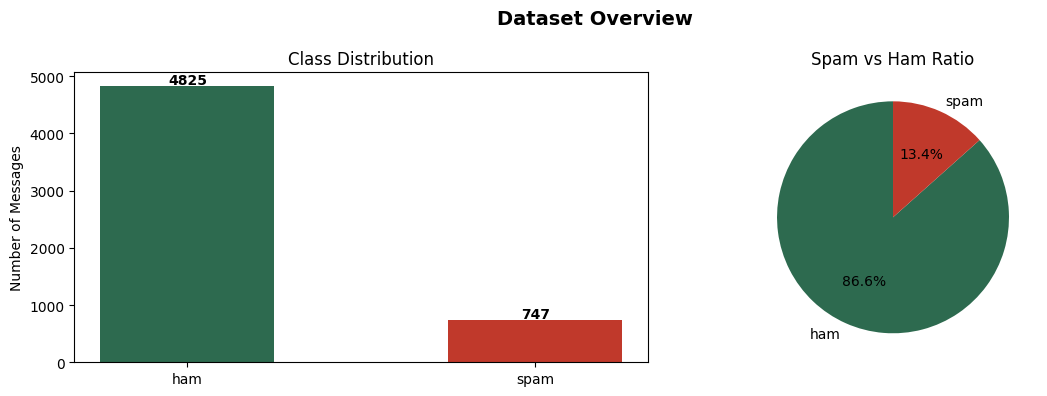

In [ ]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

# Bar chart
counts = df['label'].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=['#2d6a4f', '#c0392b'], width=0.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Messages')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30, str(val),
                 ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index,
            colors=['#2d6a4f', '#c0392b'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Spam vs Ham Ratio')

plt.tight_layout()
plt.show()

In [ ]:
def clean_text(text):
    """
    Full NLP preprocessing pipeline:
    1. Lowercase
    2. Remove HTML tags
    3. Remove URLs
    4. Remove email addresses
    5. Remove digits
    6. Remove punctuation
    7. Tokenize
    8. Remove stopwords
    9. Lemmatize
    """
    text = str(text).lower()                          # Step 1
    text = re.sub(r'<[^>]+>', ' ', text)             # Step 2
    text = re.sub(r'http\S+|www\S+', ' ', text)     # Step 3
    text = re.sub(r'\S+@\S+', ' ', text)            # Step 4
    text = re.sub(r'\d+', ' ', text)                # Step 5
    text = text.translate(                            # Step 6
               str.maketrans('', '', string.punctuation))
    tokens = text.split()                             # Step 7
    tokens = [lemmatizer.lemmatize(t) for t in tokens  # Steps 8 & 9
              if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

# Test the function
test_msg = "WINNER!! You've WON a FREE iPhone! Click http://scam.com NOW!! Call 07911123456"
print("Original :", test_msg)
print("Cleaned  :", clean_text(test_msg))

print("\n Cleaning all messages (may take ~30 seconds)...")
df['cleaned']   = df['message'].apply(clean_text)
df['label_num'] = (df['label'] == 'spam').astype(int)
df = df[df['cleaned'].str.len() > 0]  # Remove any empty results
print(f" Done! {len(df):,} messages cleaned.")
df[['label', 'message', 'cleaned']].head(3)

Original : WINNER!! You've WON a FREE iPhone! Click http://scam.com NOW!! Call 07911123456
Cleaned  : winner youve free iphone click call

 Cleaning all messages (may take ~30 seconds)...
 Done! 5,537 messages cleaned.


,label,message,cleaned
0,ham,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis great world...
1,ham,Ok lar... Joking wif u oni...,lar joking wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win cup final tkts may te...


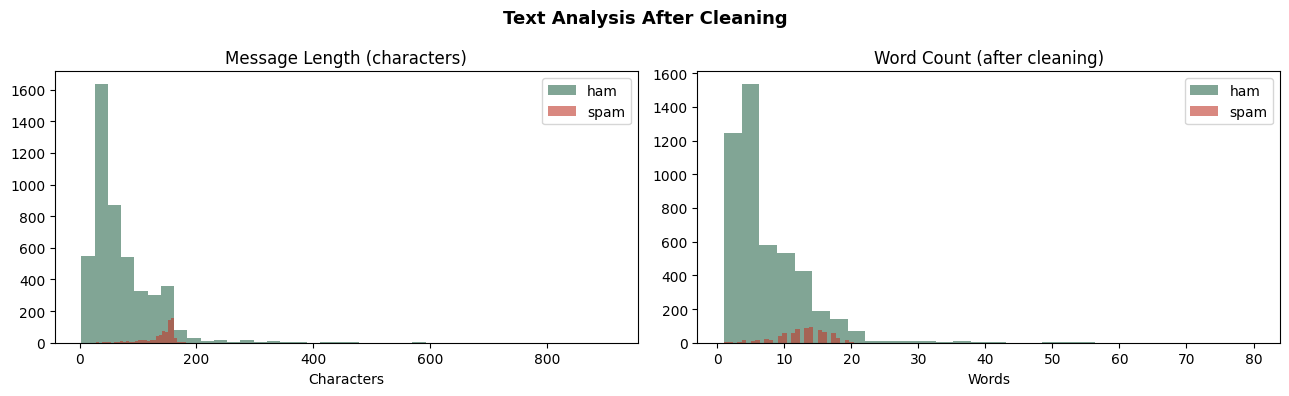

 Spam messages tend to be longer with more trigger words!


In [ ]:
# Visualize text length before and after cleaning
df['msg_len']  = df['message'].str.len()
df['word_count'] = df['cleaned'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Text Analysis After Cleaning', fontsize=13, fontweight='bold')

for label, color in [('ham','#2d6a4f'), ('spam','#c0392b')]:
    axes[0].hist(df[df['label']==label]['msg_len'],
                 bins=40, color=color, alpha=0.6, label=label)
    axes[1].hist(df[df['label']==label]['word_count'],
                 bins=30, color=color, alpha=0.6, label=label)

axes[0].set_title('Message Length (characters)')
axes[0].set_xlabel('Characters')
axes[0].legend()

axes[1].set_title('Word Count (after cleaning)')
axes[1].set_xlabel('Words')
axes[1].legend()

plt.tight_layout()
plt.show()
print(" Spam messages tend to be longer with more trigger words!")

In [ ]:
X = df['cleaned'].values
y = df['label_num'].values

# 80/20 split with stratify to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # keeps spam/ham ratio same in both splits
)

print(f"Data Split Summary")
print(f"   Training samples : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Testing samples  : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)")
print(f"   Train spam count : {y_train.sum():,}")
print(f"   Test spam count  : {y_test.sum():,}")

# TF-IDF Vectorizer for individual models
print("\n Building TF-IDF features...")
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),    # unigrams + bigrams
    max_features=10000,    # top 10,000 features
    sublinear_tf=True,     # log normalization
    min_df=2               # ignore very rare words
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print(f"TF-IDF done!")
print(f"   Vocabulary size  : {len(tfidf.vocabulary_):,} terms")
print(f"   Feature matrix   : {X_train_vec.shape}")

Data Split Summary
   Training samples : 4,429 (80%)
   Testing samples  : 1,108  (20%)
   Train spam count : 597
   Test spam count  : 149

 Building TF-IDF features...
TF-IDF done!
   Vocabulary size  : 6,678 terms
   Feature matrix   : (4429, 6678)


In [ ]:
# Model 1: Naive Bayes
print("[1/3] Training Naive Bayes...")
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train_vec, y_train)
y_pred_nb = nb.predict(X_test_vec)

nb_acc = accuracy_score(y_test, y_pred_nb)
nb_f1  = f1_score(y_test, y_pred_nb)
print(f"    Accuracy : {nb_acc*100:.2f}%")
print(f"    F1 Score : {nb_f1*100:.2f}%")

#  Model 2: Logistic Regression
print("\n[2/3] Training Logistic Regression...")
lr = LogisticRegression(
    C=5.0,
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
lr.fit(X_train_vec, y_train)
y_pred_lr = lr.predict(X_test_vec)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_f1  = f1_score(y_test, y_pred_lr)
print(f"    Accuracy : {lr_acc*100:.2f}%")
print(f"    F1 Score : {lr_f1*100:.2f}%")

# Model 3: Support Vector Machine
print("\n[3/3] Training Support Vector Machine...")
svm = CalibratedClassifierCV(
          LinearSVC(C=1.0, max_iter=2000, random_state=42)
      )   # CalibratedClassifierCV adds probability output to SVM
svm.fit(X_train_vec, y_train)
y_pred_svm = svm.predict(X_test_vec)

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_f1  = f1_score(y_test, y_pred_svm)
print(f"    Accuracy : {svm_acc*100:.2f}%")
print(f"    F1 Score : {svm_f1*100:.2f}%")

print("\nAll 3 models trained!")

[1/3] Training Naive Bayes...
    Accuracy : 97.74%
    F1 Score : 91.10%

[2/3] Training Logistic Regression...
    Accuracy : 97.92%
    F1 Score : 92.36%

[3/3] Training Support Vector Machine...
    Accuracy : 98.38%
    F1 Score : 93.84%

All 3 models trained!


In [ ]:
class SpamEnsemble(BaseEstimator, ClassifierMixin):
    """
    Soft-voting ensemble:
      20% Naive Bayes + 40% Logistic Regression + 40% SVM
    All share one TF-IDF vectorizer (unigrams + bigrams + trigrams).
    """
    def __init__(self):
        self.vectorizer = TfidfVectorizer(
            ngram_range=(1, 3),     # unigrams, bigrams, trigrams
            max_features=50000,
            sublinear_tf=True,
            min_df=1,
            max_df=0.95,
            strip_accents='unicode'
        )
        self.nb  = MultinomialNB(alpha=0.05)
        self.lr  = LogisticRegression(
                       C=10.0, max_iter=2000,
                       random_state=42, class_weight='balanced')
        self.svm = CalibratedClassifierCV(
                       LinearSVC(C=2.0, max_iter=3000,
                                 random_state=42, class_weight='balanced'))
        self.classes_ = np.array([0, 1])

    def fit(self, X, y):
        Xv = self.vectorizer.fit_transform(X)
        self.nb.fit(Xv, y)
        self.lr.fit(Xv, y)
        self.svm.fit(Xv, y)
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X):
        Xv = self.vectorizer.transform(X)
        # Weighted average of all 3 model probabilities
        return (0.20 * self.nb.predict_proba(Xv)
              + 0.40 * self.lr.predict_proba(Xv)
              + 0.40 * self.svm.predict_proba(Xv))

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

    def individual_probas(self, X):
        if isinstance(X, str):
            X = [X]
        Xv = self.vectorizer.transform(X)
        return {
            'Naive Bayes':         float(self.nb.predict_proba(Xv)[0][1]),
            'Logistic Regression': float(self.lr.predict_proba(Xv)[0][1]),
            'SVM':                 float(self.svm.predict_proba(Xv)[0][1]),
        }

print("Training ensemble model (takes ~1 min)...")
ensemble = SpamEnsemble()
ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)

ens_acc = accuracy_score(y_test, y_pred_ens)
ens_f1  = f1_score(y_test, y_pred_ens)
print(f"\n Ensemble trained!")
print(f"   Accuracy : {ens_acc*100:.2f}%")
print(f"   F1 Score : {ens_f1*100:.2f}%")

Training ensemble model (takes ~1 min)...

 Ensemble trained!
   Accuracy : 97.47%
   F1 Score : 90.85%


In [ ]:
# Build comparison table
def build_row(name, preds):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, preds) * 100, 2),
        'Precision': round(precision_score(y_test, preds, zero_division=0) * 100, 2),
        'Recall':    round(recall_score(y_test, preds, zero_division=0) * 100, 2),
        'F1 Score':  round(f1_score(y_test, preds, zero_division=0) * 100, 2),
    }

results = pd.DataFrame([
    build_row('Naive Bayes',         y_pred_nb),
    build_row('Logistic Regression', y_pred_lr),
    build_row('SVM',                 y_pred_svm),
    build_row('Ensemble',            y_pred_ens),
])


print(" FINAL MODEL COMPARISON")
print(results.to_string(index=False))

print("\n Detailed Ensemble Report:")
print(classification_report(y_test, y_pred_ens,
                            target_names=['Ham', 'Spam']))

 FINAL MODEL COMPARISON
              Model  Accuracy  Precision  Recall  F1 Score
        Naive Bayes     97.74      96.97   85.91     91.10
Logistic Regression     97.92      91.45   93.29     92.36
                SVM     98.38      95.80   91.95     93.84
           Ensemble     97.47      88.54   93.29     90.85

 Detailed Ensemble Report:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       959
        Spam       0.89      0.93      0.91       149

    accuracy                           0.97      1108
   macro avg       0.94      0.96      0.95      1108
weighted avg       0.98      0.97      0.98      1108



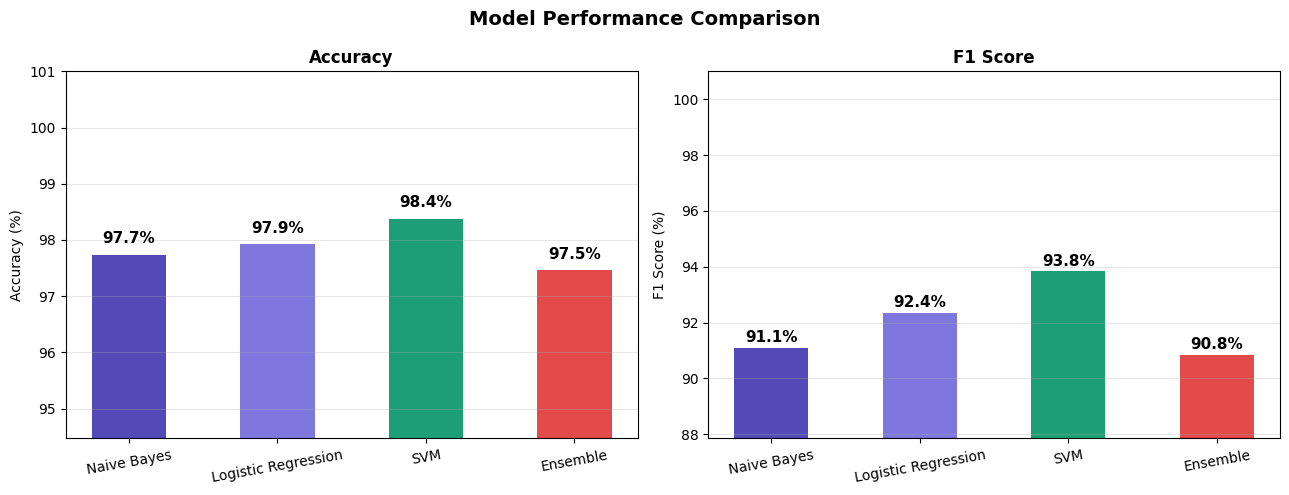

In [ ]:
# Plot model comparison
COLORS = {
    'Naive Bayes': '#534AB7',
    'Logistic Regression': '#7F77DD',
    'SVM': '#1D9E75',
    'Ensemble': '#e24b4a'
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

for ax, metric in zip(axes, ['Accuracy', 'F1 Score']):
    bars = ax.bar(
        results['Model'], results[metric],
        color=[COLORS[m] for m in results['Model']],
        width=0.5
    )
    ax.set_ylim(results[metric].min() - 3, 101)
    ax.set_ylabel(f'{metric} (%)')
    ax.set_title(metric, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=10)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f'{val:.1f}%', ha='center',
                fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

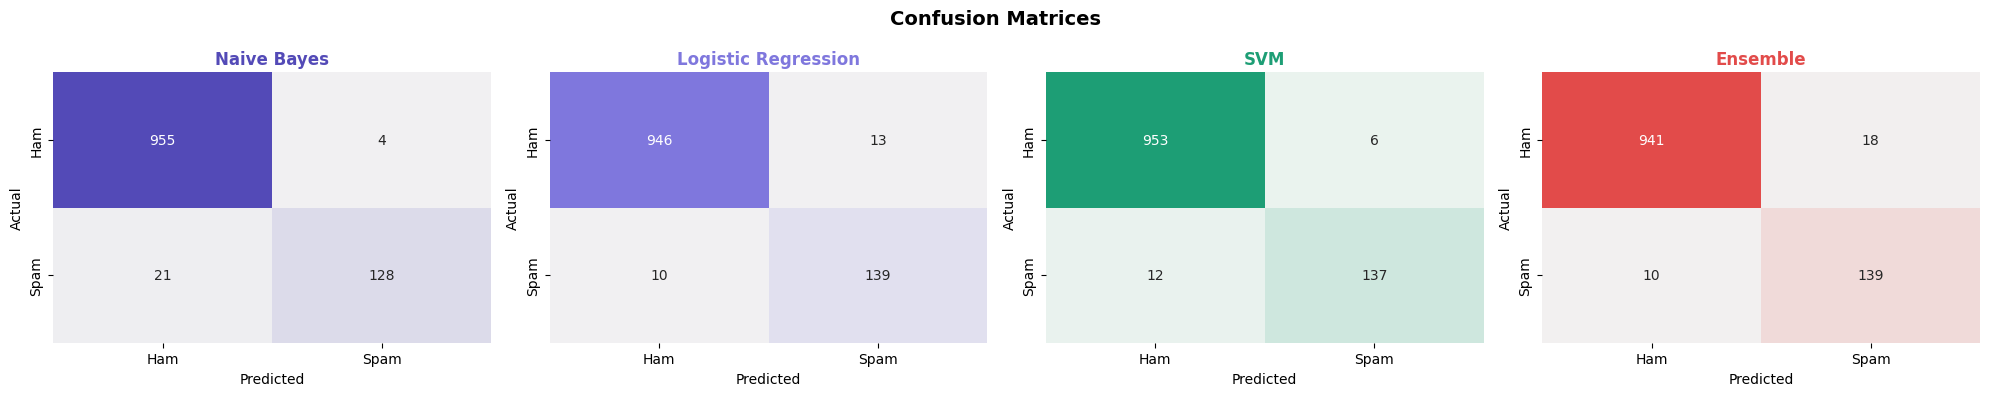

 Diagonal values = correct predictions (higher = better)
   Off-diagonal    = mistakes (lower = better)


In [ ]:
# Confusion Matrices for all 4 models
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

model_preds = [
    ('Naive Bayes',         y_pred_nb),
    ('Logistic Regression', y_pred_lr),
    ('SVM',                 y_pred_svm),
    ('Ensemble',            y_pred_ens),
]

for ax, (name, preds) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax, cbar=False,
        cmap=sns.light_palette(COLORS[name], as_cmap=True),
        xticklabels=['Ham', 'Spam'],
        yticklabels=['Ham', 'Spam']
    )
    ax.set_title(name, fontweight='bold', color=COLORS[name])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()
print(" Diagonal values = correct predictions (higher = better)")
print("   Off-diagonal    = mistakes (lower = better)")

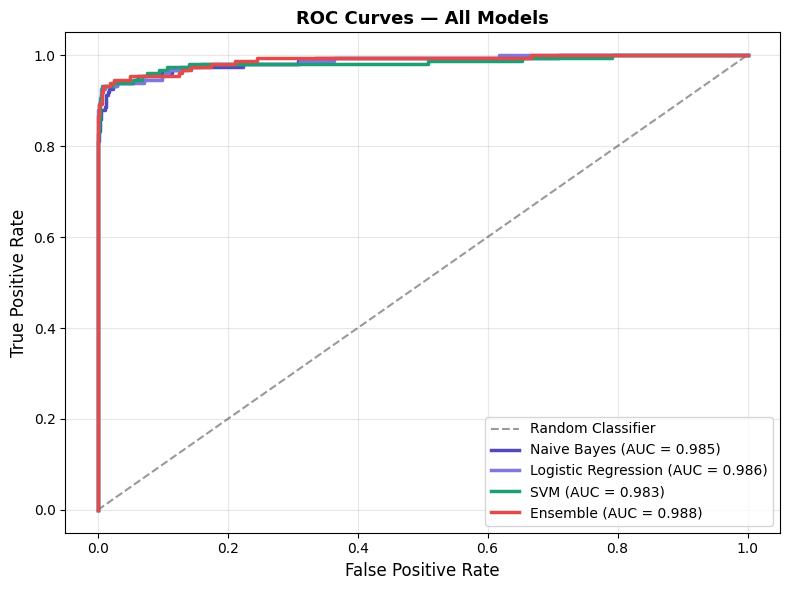

 AUC closer to 1.0 = better model
   AUC = 0.5 means random guessing


In [ ]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random Classifier')

roc_data = [
    ('Naive Bayes',         nb.predict_proba(X_test_vec)[:, 1]),
    ('Logistic Regression', lr.predict_proba(X_test_vec)[:, 1]),
    ('SVM',                 svm.predict_proba(X_test_vec)[:, 1]),
    ('Ensemble',            ensemble.predict_proba(X_test)[:, 1]),
]

for name, scores in roc_data:
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=COLORS[name], lw=2.5,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(" AUC closer to 1.0 = better model")
print("   AUC = 0.5 means random guessing")

In [ ]:
# 5-Fold Cross Validation
print(" Running 5-fold cross-validation on ensemble...")
print("   (This trains the model 5 times — takes ~3 minutes)\n")

cv_scores = cross_val_score(ensemble, X, y, cv=5, scoring='f1')

print(f"CV F1 Scores  : {cv_scores.round(4)}")
print(f"Mean CV F1    : {cv_scores.mean():.4f}")
print(f"Std Deviation : ±{cv_scores.std():.4f}")

# ROC-AUC
proba = ensemble.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, proba)
print(f"\nROC-AUC Score : {roc_auc:.4f}")


print("  ENSEMBLE FINAL RESULTS")

print(f"  Accuracy  : {ens_acc*100:.2f}%")
print(f"  F1 Score  : {ens_f1*100:.2f}%")
print(f"  ROC-AUC   : {roc_auc*100:.2f}%")
print(f"  CV Mean   : {cv_scores.mean()*100:.2f}%")


 Running 5-fold cross-validation on ensemble...
   (This trains the model 5 times — takes ~3 minutes)

CV F1 Scores  : [0.9186 0.9253 0.9265 0.8833 0.8993]
Mean CV F1    : 0.9106
Std Deviation : ±0.0168

ROC-AUC Score : 0.9876
  ENSEMBLE FINAL RESULTS
  Accuracy  : 97.47%
  F1 Score  : 90.85%
  ROC-AUC   : 98.76%
  CV Mean   : 91.06%


In [ ]:
import os
os.makedirs('models', exist_ok=True)

# Save the trained ensemble
joblib.dump(ensemble, 'models/spam_ensemble.pkl')
print("Model saved → models/spam_ensemble.pkl")

# Save metrics
best_row = results.loc[results['F1 Score'].idxmax()]
metrics = {
    'results':    results.to_dict(orient='records'),
    'best_model': best_row['Model'],
    'best_f1':    best_row['F1 Score'],
    'best_acc':   best_row['Accuracy'],
    'cv_mean_f1': round(cv_scores.mean() * 100, 2),
}
with open('models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print(" Metrics saved → models/metrics.json")

# Download model to your computer
from google.colab import files
files.download('models/spam_ensemble.pkl')
files.download('models/metrics.json')

Model saved → models/spam_ensemble.pkl
 Metrics saved → models/metrics.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def predict_message(message):
    """Predict if a message is spam or ham."""
    cleaned  = clean_text(message)
    proba    = ensemble.predict_proba([cleaned])[0]
    is_spam  = proba[1] >= 0.5
    indiv    = ensemble.individual_probas(cleaned)


    print(f"Message  : {message[:70]}..." if len(message) > 70 else f"Message  : {message}")

    print(f"Result   : {'SPAM' if is_spam else ' HAM (Legitimate)'}")
    print(f"Spam prob: {proba[1]*100:.1f}%")
    print(f"Ham prob : {proba[0]*100:.1f}%")
    print(f"\nPer model breakdown:")
    for model_name, prob in indiv.items():
        bar = '█' * int(prob * 20)
        print(f"  {model_name:22} {bar:<20} {prob*100:.1f}%")
    print()

# Test with spam messages
predict_message("WINNER!! You've been selected for a FREE £1000 prize! Call NOW!")
predict_message("Urgent! Your bank account is suspended. Verify immediately at secure-bank.com")

# Test with legitimate messages
predict_message("Hey, are you coming to the team meeting at 3pm tomorrow?")
predict_message("Please review the attached report and send feedback by Friday.")

Message  : WINNER!! You've been selected for a FREE £1000 prize! Call NOW!
Result   : SPAM
Spam prob: 99.6%
Ham prob : 0.4%

Per model breakdown:
  Naive Bayes            ███████████████████  99.7%
  Logistic Regression    ███████████████████  99.2%
  SVM                    ███████████████████  100.0%

Message  : Urgent! Your bank account is suspended. Verify immediately at secure-b...
Result   : SPAM
Spam prob: 64.4%
Ham prob : 35.6%

Per model breakdown:
  Naive Bayes            ████████████████     80.0%
  Logistic Regression    █████████            48.4%
  SVM                    ██████████████       72.7%

Message  : Hey, are you coming to the team meeting at 3pm tomorrow?
Result   :  HAM (Legitimate)
Spam prob: 0.4%
Ham prob : 99.6%

Per model breakdown:
  Naive Bayes                                 0.1%
  Logistic Regression                         0.9%
  SVM                                         0.1%

Message  : Please review the attached report and send feedback by Friday.
Re

In [ ]:
your_message = """Urgent! Your bank account is suspended. Verify immediately at secure-bank.comm"""

predict_message(your_message)

Message  : Urgent! Your bank account is suspended. Verify immediately at secure-b...
Result   : SPAM
Spam prob: 64.4%
Ham prob : 35.6%

Per model breakdown:
  Naive Bayes            ████████████████     80.0%
  Logistic Regression    █████████            48.4%
  SVM                    ██████████████       72.7%

